# Experiment 6: K-Means Clustering

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Unsupervised Learning — K-Means with Elbow Method & Silhouette Score  
**Dataset:** `Mall_Customers.csv (200 customers: Gender, Age, Annual Income, Spending Score)`  
**Lab Book Reference:** §10 K Means Clustering, page 44–48

---

## 🎯 Objective

Implement **K-Means clustering** on the Mall Customers dataset. We use the **Elbow Method** and **Silhouette Score** to determine the optimal number of clusters K, segment customers into groups, and visualise the clusters in 2-D and 3-D. Cluster interpretation provides actionable business insights for targeted marketing.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 06-K-Means-Clustering/06_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 06-K-Means-Clustering/06_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   06-K-Means-Clustering/06_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '06-K-Means-Clustering'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/06-K-Means-Clustering


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/06-K-Means-Clustering/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/06-K-Means-Clustering/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

In [3]:
data = pd.read_csv('../datasets/Mall_Customers.csv')
print(f"Shape: {data.shape}")
display(data.head())

print("\nStatistics:")
display(data.describe().round(2))

print("\nGender counts:")
print(data['Gender'].value_counts())


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,49,123,78
1,2,Female,56,65,92
2,3,Male,66,68,69
3,4,Male,69,22,47
4,5,Male,49,41,94



Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,44.46,75.58,50.02
std,57.88,15.43,35.49,29.48
min,1.00,18.00,15.00,1.00
25%,50.75,32.75,43.75,23.75
50%,100.50,46.00,73.00,49.00
75%,150.25,56.00,109.25,75.25
max,200.00,70.00,136.00,99.00



Gender counts:
Gender
Male      100
Female    100
Name: count, dtype: int64


## 3. Check for Null Values

In [4]:
print("Null values:")
print(data.isnull().sum())
print("\n✅ No missing values." if data.isnull().sum().sum() == 0 else "⚠ Handle missing values.")


Null values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ No missing values.


## 4. Exploratory Data Analysis

Visualise the distribution of customers by age, income, and spending score, and inspect how
gender affects spending behaviour.


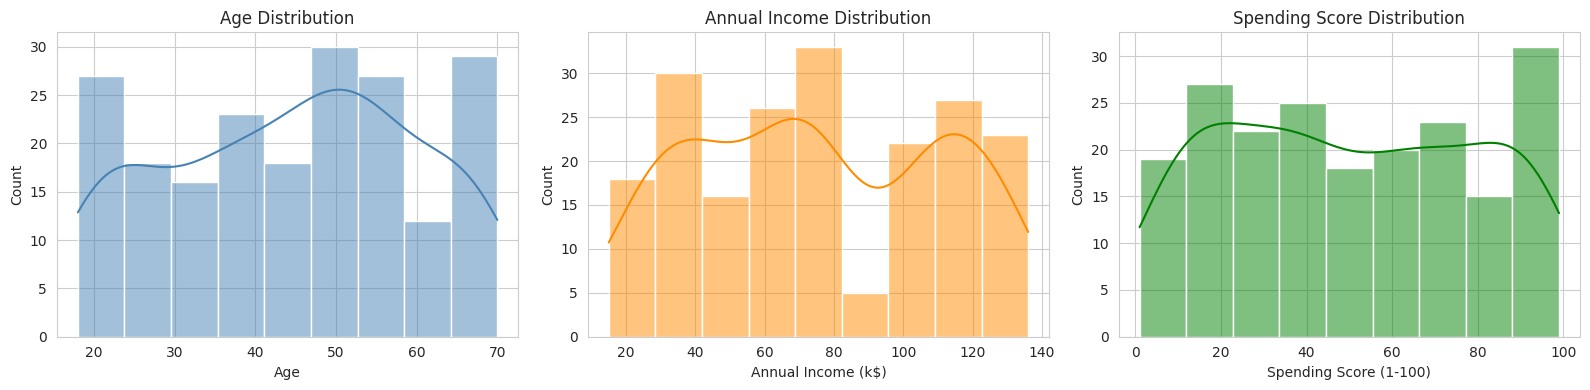

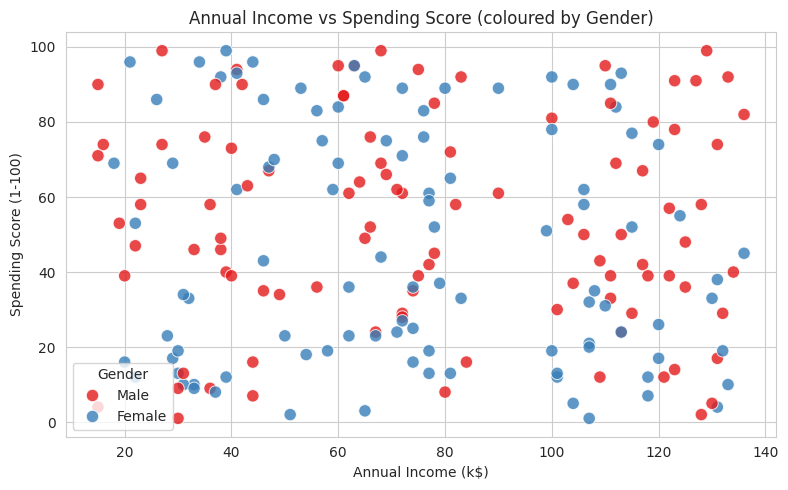

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data['Age'],                 kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
sns.histplot(data['Annual Income (k$)'],  kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Annual Income Distribution')
sns.histplot(data['Spending Score (1-100)'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Gender', palette='Set1', s=80, alpha=0.8)
plt.title('Annual Income vs Spending Score (coloured by Gender)')
plt.tight_layout()
plt.show()


## 5. Select Features for Clustering

We cluster on **Annual Income** and **Spending Score** — the classic 2-D customer-segmentation
setup that yields 5 natural clusters.


In [6]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
print(f"Features shape: {X.shape}")


Features shape: (200, 2)


## 6. Feature Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features standardised.")


Features standardised.


## 7. Find Optimal K — Elbow Method + Silhouette Score

The **Elbow Method** plots Within-Cluster-Sum-of-Squares (WCSS / inertia) vs K; the "elbow"
indicates the optimal K. The **Silhouette Score** (range −1 to 1) measures how similar a
point is to its own cluster vs other clusters; higher = better.


,K,WCSS (Inertia),Silhouette
0,2,241.1920,0.3729
1,3,144.4557,0.4198
2,4,94.7517,0.4289
3,5,77.2997,0.4188
4,6,60.4950,0.4064
5,7,49.9383,0.4116
6,8,40.1288,0.4375
7,9,33.7383,0.4368
8,10,29.6481,0.4515


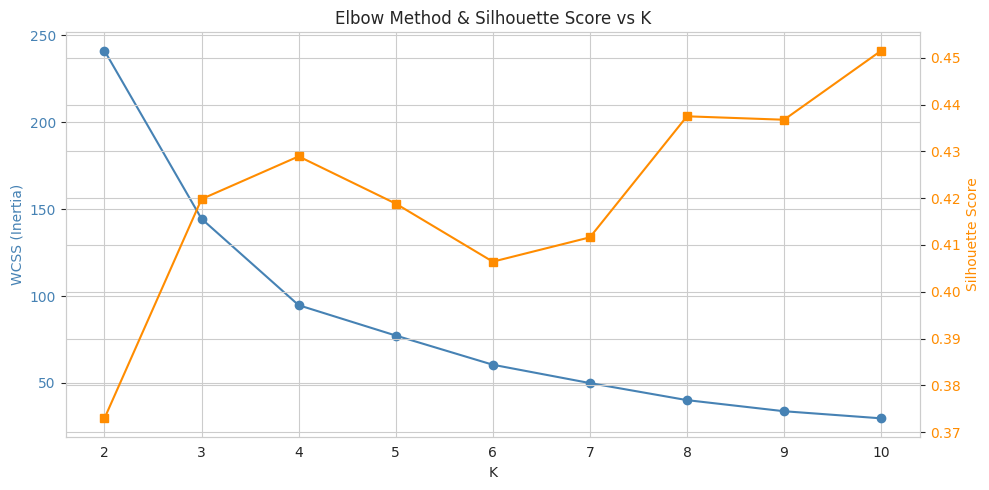


Selected K = 5 (clear elbow + strong silhouette)


In [8]:
K_range = range(2, 11)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

results = pd.DataFrame({
    'K'              : list(K_range),
    'WCSS (Inertia)' : inertias,
    'Silhouette'     : silhouettes,
}).round(4)
display(results)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertias, 'o-', color='steelblue', label='WCSS')
ax1.set_xlabel('K')
ax1.set_ylabel('WCSS (Inertia)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 's-', color='darkorange', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
plt.title('Elbow Method & Silhouette Score vs K')
fig.tight_layout()
plt.show()

optimal_k = 5  # standard for Mall_Customers dataset
print(f"\nSelected K = {optimal_k} (clear elbow + strong silhouette)")


## 8. Train K-Means with Optimal K

In [9]:
kmeans = KMeans(n_clusters=optimal_k, init='k-means++',
                random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

data['Cluster'] = y_kmeans
print(f"Cluster assignments: {y_kmeans}")
print(f"Cluster centres (scaled):\n{kmeans.cluster_centers_}")
print(f"\nInertia (WCSS): {kmeans.inertia_:.4f}")
print(f"Silhouette     : {silhouette_score(X_scaled, y_kmeans):.4f}")


Cluster assignments: [3 4 4 0 0 0 3 0 1 3 0 2 4 2 1 4 1 1 0 1 4 4 1 1 3 0 2 4 2 1 2 3 1 0 2 3 4
 1 2 2 1 2 2 4 2 1 2 0 4 1 1 3 2 1 1 1 2 4 1 2 1 4 3 0 1 0 2 0 3 1 2 0 0 4
 2 1 4 2 1 2 0 2 4 0 1 0 1 3 0 1 1 4 0 1 1 3 1 1 4 3 2 1 3 3 4 0 2 4 2 1 1
 4 1 4 1 4 1 3 4 4 4 1 0 4 2 1 2 3 0 1 1 3 2 0 2 4 1 2 3 2 2 4 3 4 1 4 1 0
 3 2 1 1 1 2 1 1 2 1 4 2 2 2 2 4 1 0 0 2 0 4 2 1 2 0 2 2 4 3 2 3 3 0 1 1 3
 1 1 4 0 2 3 4 4 1 1 1 3 3 4 0]
Cluster centres (scaled):
[[-1.22194488  0.90634338]
 [-0.66376351 -0.87636172]
 [ 1.15783897 -0.79659161]
 [ 1.14465799  0.95131911]
 [-0.15700476  0.8886764 ]]

Inertia (WCSS): 77.2997
Silhouette     : 0.4188


## 9. Visualise the Clusters

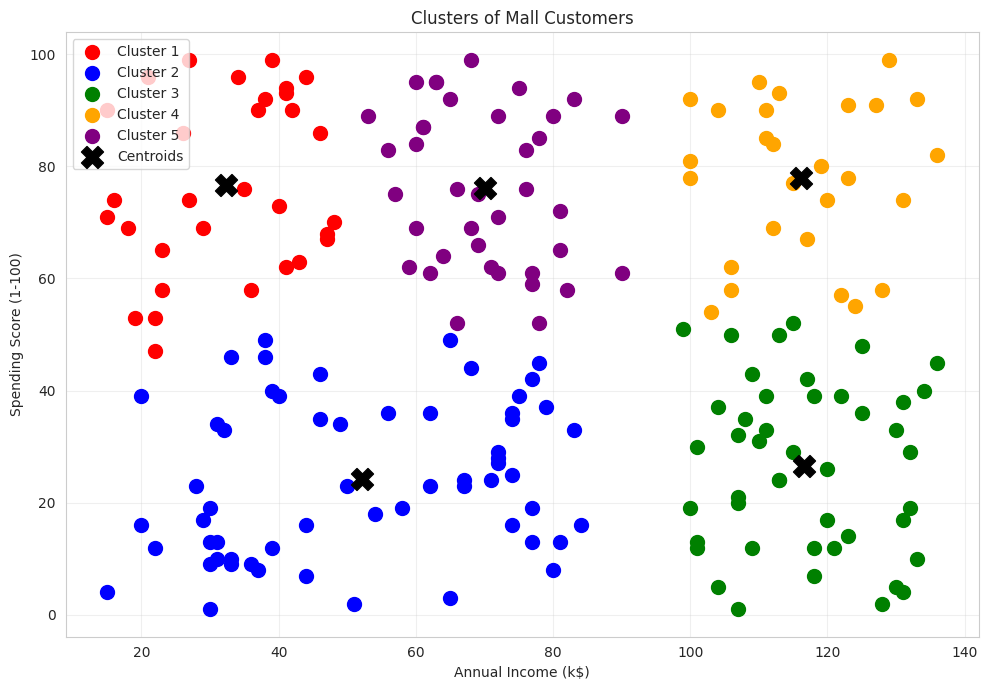

In [10]:
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(optimal_k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=100, c=colors[i],
                label=f'Cluster {i+1}')

# Plot centroids (back-transform to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            s=250, c='black', marker='X', label='Centroids')

plt.title('Clusters of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Cluster Analysis & Business Interpretation

In [11]:
summary = data.groupby('Cluster').agg({
    'Age'                       : 'mean',
    'Annual Income (k$)'        : 'mean',
    'Spending Score (1-100)'    : 'mean',
    'CustomerID'                : 'count',
}).rename(columns={'CustomerID': 'Count'}).round(2)
display(summary)

interpretations = {
    0: '⚪ Careful — High income, low spending (potential upsell target)',
    1: '🟢 Standard — Average income, average spending',
    2: '🎯 Target — High income, high spending (VIP customers)',
    3: '🔵 Sensible — Low income, low spending',
    4: '🟡 Careless — Low income, high spending (impulsive buyers)',
}
print("\nCluster Interpretation:")
for c, desc in interpretations.items():
    print(f"  Cluster {c}: {desc}")


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,44.45,32.32,76.68,31
1,43.64,52.08,24.25,59
2,41.64,116.58,26.60,45
3,52.07,116.11,78.00,27
4,43.63,70.03,76.16,38



Cluster Interpretation:
  Cluster 0: ⚪ Careful — High income, low spending (potential upsell target)
  Cluster 1: 🟢 Standard — Average income, average spending
  Cluster 2: 🎯 Target — High income, high spending (VIP customers)
  Cluster 3: 🔵 Sensible — Low income, low spending
  Cluster 4: 🟡 Careless — Low income, high spending (impulsive buyers)


## 11. 3-D Clustering (Age, Income, Spending Score)

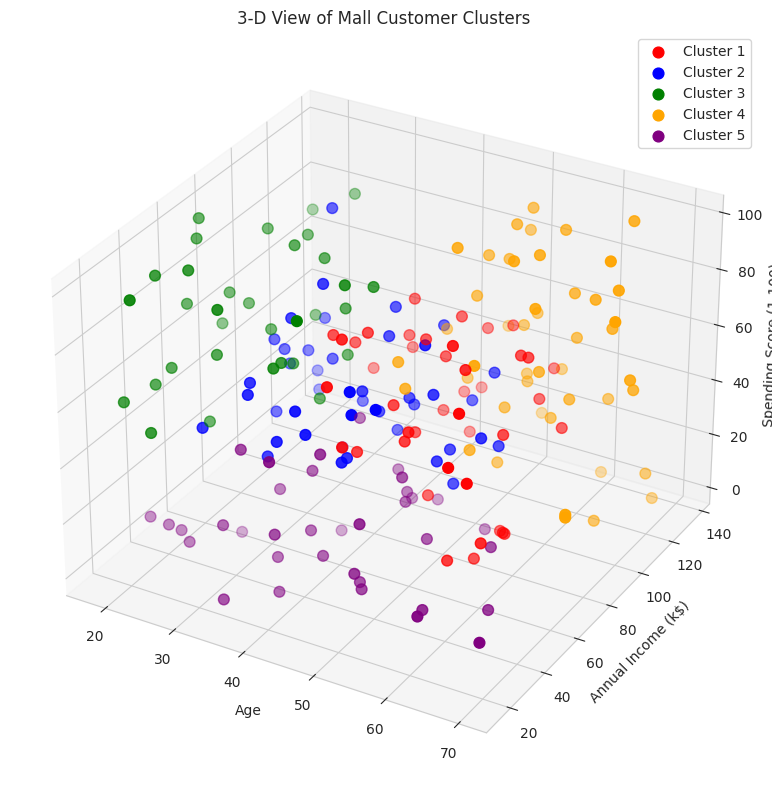

In [12]:
from mpl_toolkits.mplot3d import Axes3D

X_3d = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
X_3d_scaled = StandardScaler().fit_transform(X_3d)

kmeans_3d = KMeans(n_clusters=optimal_k, init='k-means++',
                  random_state=42, n_init=10)
labels_3d = kmeans_3d.fit_predict(X_3d_scaled)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
for i in range(optimal_k):
    ax.scatter(X_3d[labels_3d == i, 0], X_3d[labels_3d == i, 1], X_3d[labels_3d == i, 2],
               s=60, color=colors[i], label=f'Cluster {i+1}')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3-D View of Mall Customer Clusters')
ax.legend()
plt.tight_layout()
plt.show()


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Implement K-Means on the **Old Faithful Geyser** dataset — segment waiting time between eruptions and the duration of the eruption.
2. Use K-Means to **compress an image** of size 396 × 396 × 3 (cluster the pixel colours and replace each pixel with its centroid colour).
3. Compare K-Means with **Agglomerative Clustering** and **DBSCAN** on the Mall_Customers dataset using the silhouette score.


---

## 📚 Key Takeaways

- **K-Means** is an unsupervised clustering algorithm — partitions data into K groups.
- **Elbow Method** + **Silhouette Score** together identify the optimal K.
- **k-means++** initialisation avoids poor random seeds and gives more stable results.
- **Sensitive to outliers** and to feature scaling — always standardise first.
- **Limitations:** assumes spherical clusters of similar size; struggles with non-convex shapes (use DBSCAN or Spectral Clustering instead).

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
